# Plant Detection using TensorFlow Object Detection API

This notebook demonstrates training and evaluation of an object detection model
for plant instance detection on the :contentReference[oaicite:0]{index=0} dataset.

We fine-tune a pre-trained SSD model:
- Model: SSD MobileNet V2 FPNLite (320×320)
- Framework: TensorFlow Object Detection API (TF 2.11)
- Task: Crop vs Weed detection

The notebook covers:
1. Environment setup
2. Dataset loading
3. Model configuration
4. Training and evaluation
5. Qualitative inference results

## Environment Setup

This experiment is designed for:
- Python 3.10
- TensorFlow 2.11
- CUDA-enabled GPU

On Kaggle:
Enable "Pin to original environment" to avoid version drift.

In [1]:
!python -V

Python 3.10.10


In [2]:
# --- Core: minimal + compatible setup for TF 2.11 OD API ---

  # numpy==1.23.5 \
  # scipy==1.10.1 \

!pip install -q \
  numpy==1.22.4 \
  scipy==1.10.1 \
  protobuf==3.20.3 \
  tf_slim \
  pycocotools \
  lvis \
  Cython \
  contextlib2 \
  pillow \
  matplotlib \
  gin-config \
  tf-models-official==2.11.0 --no-deps

In [3]:
!pip install \
  --upgrade \
  --force-reinstall \
  --no-cache-dir \
  --no-deps \
  git+https://github.com/frdiener/agri-vision-edge.git

  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-nm7yzaxb
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-nm7yzaxb
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit 46ce7ff0d2fff931652e1a7f2d4f186ac5acd7fd
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1792629 sha256=834fbe254791788b5e7e653d0ae13e1cc22796d462e079ccc452133c39348c87
  Stored in directory: /tmp/pip-ephem-wheel-cache-v99pa0rs/wheels/47/ca/b5/23e0d1c70f8dbe929aaa72754dafc87b1c07721c0795e427ff
Successfully built agri-vision-edge


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU ready:", gpus)

GPU ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from agri_vision_edge.third_party import setup_tensorflow_models
setup_tensorflow_models()

import object_detection
import google.protobuf

print("TF:", tf.__version__)
print("protobuf:", google.protobuf.__version__)

TF: 2.11.0
protobuf: 3.20.3


## Dataset

We use preprocessed TFRecord files derived from :contentReference[oaicite:1]{index=1}.

Additionally, raw images are used for qualitative evaluation.

In [6]:
from pathlib import Path
import agri_vision_edge

dataset_dir = Path("/kaggle/input/notebooks/freimutdiener/phenobench-tensorflow-od-dataset-export")
dataset_raw_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-raw-dataset-v1-1-0/PhenoBench")

label_map_path = dataset_dir / "label_map.pbtxt"
train_record = dataset_dir / "train.record"
val_record = dataset_dir / "val.record"

test_imgs = list((dataset_raw_dir / "test" / "images").glob("*.png"))

print(f"{len(test_imgs)} test images loaded")

693 test images loaded


## Model Configuration

We fine-tune a pre-trained SSD model:
- Backbone: MobileNetV2
- Feature extractor: FPNLite
- Input size: 320×320

We adapt:
- number of classes
- learning rate schedule
- dataset paths

In [7]:
from agri_vision_edge.tfod import configure_ssd_pipeline

MODEL_DIR = Path("/kaggle/input/models/freimutdiener/ssd-mobilenet-v2-fpnlite-320x320-coco17-tpu-8/tensorflow2/default/1/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8")

PIPELINE_CONFIG = Path("/kaggle/working/pipeline.config")

configure_ssd_pipeline(
    config_path=MODEL_DIR / "pipeline.config",
    output_path=PIPELINE_CONFIG,
    train_record=train_record,
    val_record=val_record,
    label_map=label_map_path,
    checkpoint_path=MODEL_DIR / "checkpoint" / "ckpt-0",
    num_classes=2,
    batch_size=4,  # should really be more for stable gradient
    learning_rate_base=0.001,
    warmup_learning_rate=0.0002,
    num_steps=50_000,
    warmup_steps=500,

)

## Training

We train for 10,000 steps using fine-tuning from COCO weights.

In [8]:
from agri_vision_edge.tfod import launch_training

training_process = launch_training(
    pipeline_config_path=PIPELINE_CONFIG,
    model_dir="/kaggle/working/training",
    checkpoint_every_n=250,
    log_file="train.log",
    background=False,
)

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
I0507 10:11:51.282897 139640807343936 mirrored_strategy.py:374] Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
I0507 10:11:51.287862 139640807343936 config_util.py:552] Maybe overwriting train_steps: None
I0507 10:11:51.288048 139640807343936 config_util.

## Training Metrics and Learning Curves

The TensorFlow Object Detection API writes training metrics
as TensorBoard event files during optimization.

We parse these logs to generate publication-quality plots
for:

- total training loss
- classification loss
- localization loss
- learning rate schedule
- training throughput

These figures can later be exported directly for inclusion
in reports, presentations, or academic theses.

In [9]:
from agri_vision_edge.evaluation import (
    load_event_scalars,
    plot_loss_curves,
    plot_learning_rate,
    plot_steps_per_second,
    available_tags,
)

train_df = load_event_scalars(
    "/kaggle/working/training/train"
)

print("Available TensorBoard tags:")
for tag in available_tags(train_df):
    print("-", tag)

Available TensorBoard tags:
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- learning_rate
- steps_per_sec


(<Figure size 800x500 with 1 Axes>,
 <AxesSubplot: title={'center': 'Training Loss'}, xlabel='Training Step', ylabel='Loss'>)

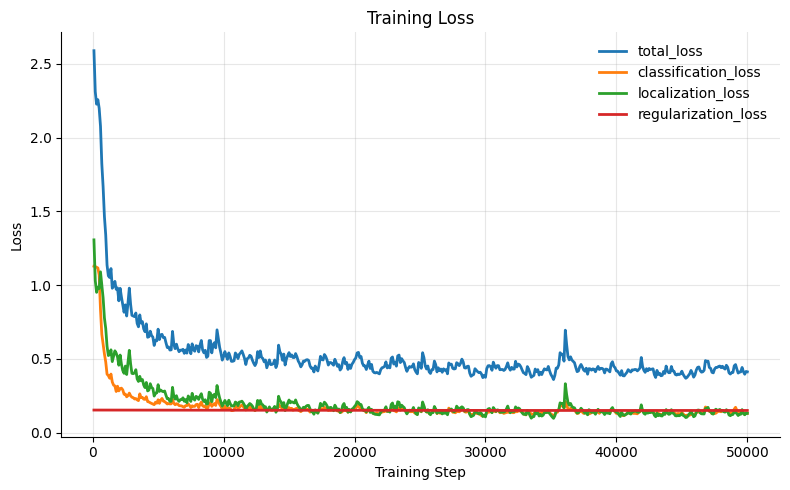

In [10]:
plot_loss_curves(
    train_df,
    smoothing=0.6,
    save_path="training_loss_curves.pdf",
)

(<Figure size 800x400 with 1 Axes>,
 <AxesSubplot: title={'center': 'Learning Rate Schedule'}, xlabel='Training Step', ylabel='Learning Rate'>)

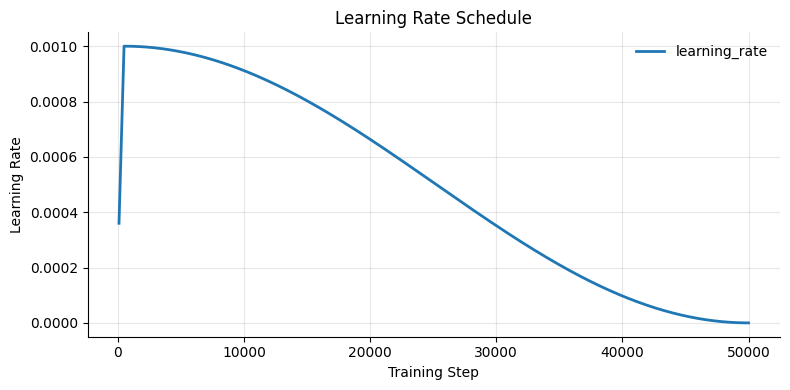

In [11]:
plot_learning_rate(
    train_df,
    save_path="learning_rate_schedule.pdf",
)

(<Figure size 800x400 with 1 Axes>,
 <AxesSubplot: title={'center': 'Training Throughput'}, xlabel='Training Step', ylabel='Steps / Second'>)

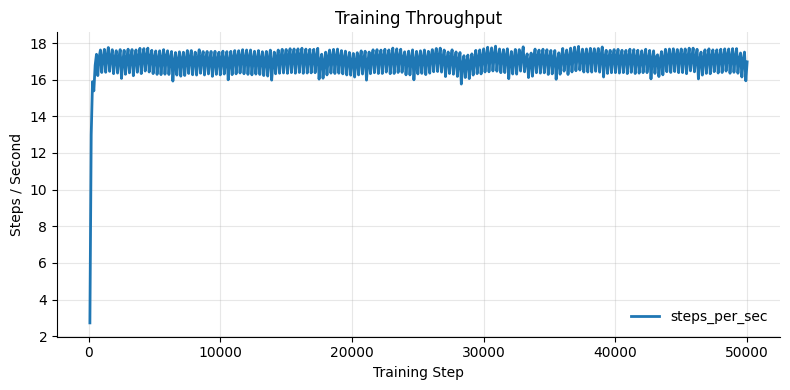

In [12]:
plot_steps_per_second(
    train_df,
    smoothing=0.5,
    save_path="training_throughput.pdf",
)

The generated figures are also exported as PDF files:

- `training_loss_curves.pdf`
- `learning_rate_schedule.pdf`
- `training_throughput.pdf`

These vector graphics are suitable for direct inclusion
in scientific publications and LaTeX-based theses.

In [13]:
# from agri_vision_edge.tfod import launch_eval

# launch_eval(
#     pipeline_config_path=PIPELINE_CONFIG,
#     checkpoint_dir="/kaggle/working/training",
#     model_dir="/kaggle/working/eval_output",
# )


## Validation and Checkpoint Selection

Instead of evaluating only the final checkpoint,
we evaluate all saved checkpoints throughout training.

This enables:

- training progression analysis
- mAP evolution tracking
- best checkpoint selection
- overfitting detection

In [14]:
from agri_vision_edge.evaluation import (
    evaluate_checkpoints,
    find_best_checkpoint,
)

metrics_df = evaluate_checkpoints(
    pipeline_config_path=PIPELINE_CONFIG,
    checkpoint_dir="/kaggle/working/training",
    output_dir="/kaggle/working/eval_checkpoints",
)

metrics_df

Evaluating checkpoint 161
<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
W0507 11:02:27.892996 140070354532160 model_lib_v2.py:1089] Forced number of epochs for all eval validations to be 1.
I0507 11:02:27.893217 140070354532160 config_util.py:552] Maybe overwriting sample_1_of_n_eval_examples: None
I0507 11:02:27.893285 140070354532160 co

,DetectionBoxes_Precision/mAP,DetectionBoxes_Precision/mAP@.50IOU,DetectionBoxes_Precision/mAP@.75IOU,DetectionBoxes_Precision/mAP (small),DetectionBoxes_Precision/mAP (medium),DetectionBoxes_Precision/mAP (large),DetectionBoxes_Recall/AR@1,DetectionBoxes_Recall/AR@10,DetectionBoxes_Recall/AR@100,DetectionBoxes_Recall/AR@100 (small),DetectionBoxes_Recall/AR@100 (medium),DetectionBoxes_Recall/AR@100 (large),Loss/localization_loss,Loss/classification_loss,Loss/regularization_loss,Loss/total_loss,checkpoint,step
0,0.298661,0.489476,0.311867,0.143921,0.602361,0.376155,0.072885,0.343977,0.410403,0.287082,0.703471,0.399587,0.206290,0.175175,0.150631,0.532095,/kaggle/working/training/ckpt-161,161
1,0.299135,0.490944,0.312343,0.144561,0.602325,0.376303,0.072818,0.343653,0.411287,0.288302,0.703397,0.400000,0.206046,0.175082,0.150631,0.531759,/kaggle/working/training/ckpt-162,162
2,0.299704,0.492191,0.312673,0.145207,0.602202,0.376891,0.073021,0.344144,0.412179,0.289277,0.703397,0.400000,0.205611,0.175107,0.150630,0.531349,/kaggle/working/training/ckpt-163,163
3,0.299686,0.492283,0.311519,0.144960,0.601980,0.376649,0.073162,0.345332,0.412411,0.289435,0.703273,0.400826,0.205093,0.175062,0.150630,0.530785,/kaggle/working/training/ckpt-164,164
4,0.299710,0.492050,0.311461,0.145358,0.601465,0.376669,0.073047,0.344988,0.412630,0.289904,0.702703,0.400413,0.205188,0.175015,0.150630,0.530834,/kaggle/working/training/ckpt-165,165
5,0.299608,0.492160,0.311916,0.145313,0.601883,0.376741,0.073041,0.344625,0.412209,0.289316,0.703546,0.399793,0.205181,0.174993,0.150630,0.530805,/kaggle/working/training/ckpt-166,166
6,0.299454,0.492087,0.312220,0.144952,0.602118,0.375761,0.073046,0.345039,0.411598,0.288443,0.703496,0.399793,0.205350,0.175020,0.150630,0.531000,/kaggle/working/training/ckpt-167,167


## Validation Metrics

We evaluate all saved checkpoints using standard
COCO-style object detection metrics.

This enables analysis of:

- convergence behavior
- validation performance evolution
- checkpoint selection
- potential overfitting

In [15]:
metrics_df.columns

Index(['DetectionBoxes_Precision/mAP', 'DetectionBoxes_Precision/mAP@.50IOU',
       'DetectionBoxes_Precision/mAP@.75IOU',
       'DetectionBoxes_Precision/mAP (small)',
       'DetectionBoxes_Precision/mAP (medium)',
       'DetectionBoxes_Precision/mAP (large)', 'DetectionBoxes_Recall/AR@1',
       'DetectionBoxes_Recall/AR@10', 'DetectionBoxes_Recall/AR@100',
       'DetectionBoxes_Recall/AR@100 (small)',
       'DetectionBoxes_Recall/AR@100 (medium)',
       'DetectionBoxes_Recall/AR@100 (large)', 'Loss/localization_loss',
       'Loss/classification_loss', 'Loss/regularization_loss',
       'Loss/total_loss', 'checkpoint', 'step'],
      dtype='object')

In [16]:
metrics_df[
    [
        "step",
        "DetectionBoxes_Precision/mAP",
        "DetectionBoxes_Precision/mAP@.50IOU",
        "DetectionBoxes_Precision/mAP@.75IOU",
        "DetectionBoxes_Recall/AR@100",
    ]
]

,step,DetectionBoxes_Precision/mAP,DetectionBoxes_Precision/mAP@.50IOU,DetectionBoxes_Precision/mAP@.75IOU,DetectionBoxes_Recall/AR@100
0,161,0.298661,0.489476,0.311867,0.410403
1,162,0.299135,0.490944,0.312343,0.411287
2,163,0.299704,0.492191,0.312673,0.412179
3,164,0.299686,0.492283,0.311519,0.412411
4,165,0.299710,0.492050,0.311461,0.412630
5,166,0.299608,0.492160,0.311916,0.412209
6,167,0.299454,0.492087,0.312220,0.411598


In [17]:
metrics_df

,DetectionBoxes_Precision/mAP,DetectionBoxes_Precision/mAP@.50IOU,DetectionBoxes_Precision/mAP@.75IOU,DetectionBoxes_Precision/mAP (small),DetectionBoxes_Precision/mAP (medium),DetectionBoxes_Precision/mAP (large),DetectionBoxes_Recall/AR@1,DetectionBoxes_Recall/AR@10,DetectionBoxes_Recall/AR@100,DetectionBoxes_Recall/AR@100 (small),DetectionBoxes_Recall/AR@100 (medium),DetectionBoxes_Recall/AR@100 (large),Loss/localization_loss,Loss/classification_loss,Loss/regularization_loss,Loss/total_loss,checkpoint,step
0,0.298661,0.489476,0.311867,0.143921,0.602361,0.376155,0.072885,0.343977,0.410403,0.287082,0.703471,0.399587,0.206290,0.175175,0.150631,0.532095,/kaggle/working/training/ckpt-161,161
1,0.299135,0.490944,0.312343,0.144561,0.602325,0.376303,0.072818,0.343653,0.411287,0.288302,0.703397,0.400000,0.206046,0.175082,0.150631,0.531759,/kaggle/working/training/ckpt-162,162
2,0.299704,0.492191,0.312673,0.145207,0.602202,0.376891,0.073021,0.344144,0.412179,0.289277,0.703397,0.400000,0.205611,0.175107,0.150630,0.531349,/kaggle/working/training/ckpt-163,163
3,0.299686,0.492283,0.311519,0.144960,0.601980,0.376649,0.073162,0.345332,0.412411,0.289435,0.703273,0.400826,0.205093,0.175062,0.150630,0.530785,/kaggle/working/training/ckpt-164,164
4,0.299710,0.492050,0.311461,0.145358,0.601465,0.376669,0.073047,0.344988,0.412630,0.289904,0.702703,0.400413,0.205188,0.175015,0.150630,0.530834,/kaggle/working/training/ckpt-165,165
5,0.299608,0.492160,0.311916,0.145313,0.601883,0.376741,0.073041,0.344625,0.412209,0.289316,0.703546,0.399793,0.205181,0.174993,0.150630,0.530805,/kaggle/working/training/ckpt-166,166
6,0.299454,0.492087,0.312220,0.144952,0.602118,0.375761,0.073046,0.345039,0.411598,0.288443,0.703496,0.399793,0.205350,0.175020,0.150630,0.531000,/kaggle/working/training/ckpt-167,167


(<Figure size 800x500 with 1 Axes>,
 <AxesSubplot: title={'center': 'Validation Detection Metrics'}, xlabel='Checkpoint Step', ylabel='Metric Value'>)

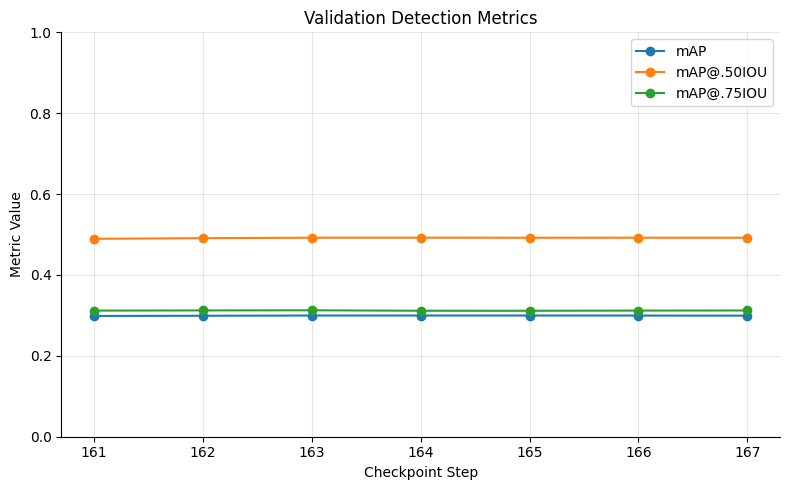

In [18]:
from agri_vision_edge.evaluation import plot_checkpoint_metrics

plot_checkpoint_metrics(
    metrics_df,
)

In [19]:
best_checkpoint = find_best_checkpoint(
    metrics_df,
    metric="DetectionBoxes_Precision/mAP",
)

best_checkpoint

DetectionBoxes_Precision/mAP                                       0.29971
DetectionBoxes_Precision/mAP@.50IOU                                0.49205
DetectionBoxes_Precision/mAP@.75IOU                               0.311461
DetectionBoxes_Precision/mAP (small)                              0.145358
DetectionBoxes_Precision/mAP (medium)                             0.601465
DetectionBoxes_Precision/mAP (large)                              0.376669
DetectionBoxes_Recall/AR@1                                        0.073047
DetectionBoxes_Recall/AR@10                                       0.344988
DetectionBoxes_Recall/AR@100                                       0.41263
DetectionBoxes_Recall/AR@100 (small)                              0.289904
DetectionBoxes_Recall/AR@100 (medium)                             0.702703
DetectionBoxes_Recall/AR@100 (large)                              0.400413
Loss/localization_loss                                            0.205188
Loss/classification_loss 

## Model Export

We export the trained model to TensorFlow SavedModel format
for inference and deployment.

In [20]:
from agri_vision_edge.tfod import export_saved_model

export_saved_model(
    pipeline_config_path=PIPELINE_CONFIG,
    trained_checkpoint_dir="/kaggle/working/training",
    checkpoint_path=best_checkpoint["checkpoint"],
    output_directory="/kaggle/working/exported_model",
)

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
W0507 11:09:22.708896 138924131555136 deprecation.py:350] From /opt/conda/lib/python3.10/site-packages/tensorflow/python/autograph/pyct/static_analysis/liveness.py:83: Analyzer.lamba_check (from tensorflow.python.autograph.pyct.static_analysis.liveness) is deprecated and will be removed after 

<Popen: returncode: 0 args: ['python', '/opt/conda/lib/python3.10/site-packa...>

## Qualitative Evaluation

We visualize predictions on unseen test images.

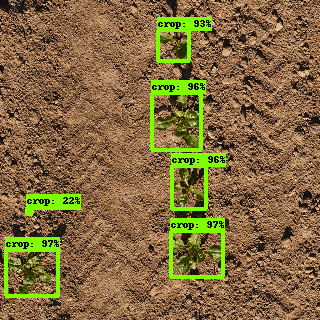

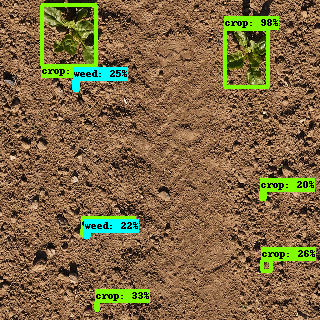

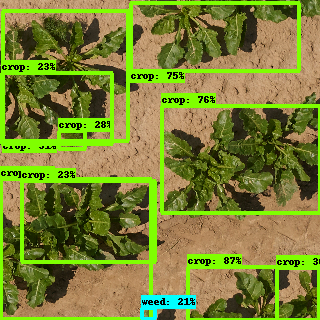

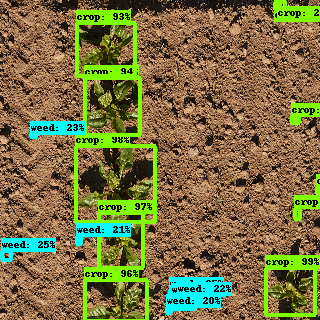

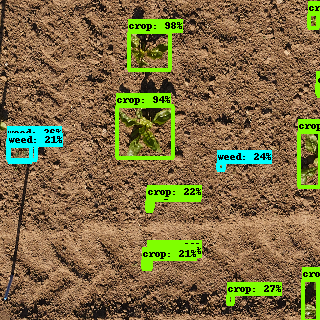

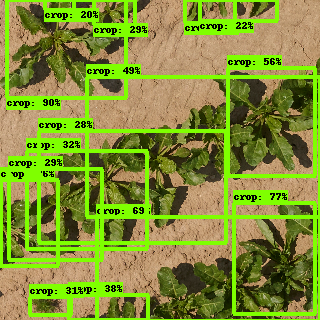

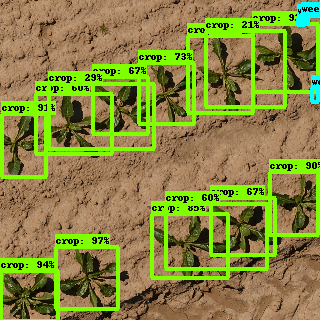

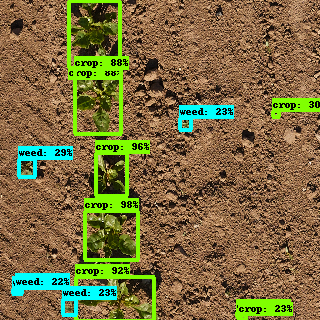

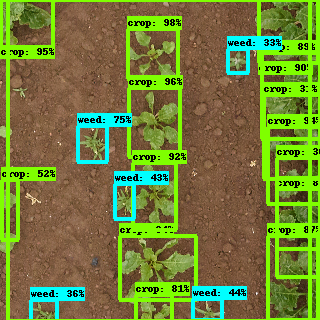

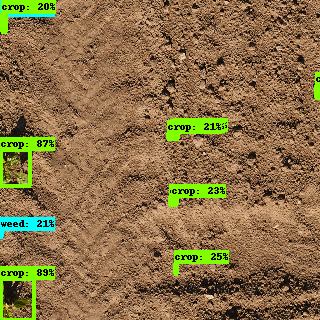

In [21]:
from IPython.display import display
from agri_vision_edge.tfod.inference import (
    load_saved_model,
    load_label_map,
    detect_image,
)

detect_fn = load_saved_model(
    "/kaggle/working/exported_model/saved_model"
)

category_index = load_label_map(label_map_path)

for image_path in test_imgs[:10]:
    vis, _ = detect_image(
        detect_fn=detect_fn,
        image_path=image_path,
        category_index=category_index,
        image_size=320,
        score_threshold=0.2,
        max_boxes=20,
    )
    display(vis)

## Discussion

The model demonstrates:

- Successful localization of plant instances
- Overlapping detections reduced via NMS
- Sensitivity to small objects (PhenoBench-specific challenge)

Limitations:
- Performance depends strongly on resolution (320×320)
- Dense scenes produce multiple candidate detections
- Further improvements possible via:
  - anchor tuning
  - longer training
  - quantization-aware training (QAT)

Future work:
- INT8 deployment via TFLite
- Real-time inference optimization